In [4]:
"""
Cash Flow Matching and Portfolio Optimization
Dedication vs Immunization: Liability-Driven Portfolio Optimization
主程序文件
"""

import numpy as np
import pandas as pd
from scipy.optimize import linprog
from scipy import interpolate
import matplotlib.pyplot as plt
import os

# 设置中文显示（可选）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

print("=" * 60)
print("开始运行负债驱动投资组合优化项目")
print("=" * 60)

# 创建结果文件夹（如果不存在）
os.makedirs('results', exist_ok=True)
os.makedirs('images', exist_ok=True)

# 1. 加载数据
print("\n[1] 加载数据...")

# 负债数据
liabilities = pd.read_csv('data/liabilities.csv')
liabilities['Total'] = liabilities['Payment']
print(f"   负债总金额: ${liabilities['Total'].sum():.2f} 亿元")

# 国债收益率数据
treasury = pd.read_csv('data/treasury_rates.csv')
print(f"   国债收益率数据点: {len(treasury)} 个")

# 债券数据
bonds = pd.read_csv('data/bonds.csv')
print(f"   可选债券: {len(bonds)} 种")

开始运行负债驱动投资组合优化项目

[1] 加载数据...
   负债总金额: $5211.55 亿元
   国债收益率数据点: 8 个
   可选债券: 135 种



[2] 计算负债现值...
   各年收益率: {np.int64(1): np.float64(1.27), np.int64(2): np.float64(1.34), np.int64(3): np.float64(1.36), np.int64(4): np.float64(1.47), np.int64(5): np.float64(1.58), np.int64(6): np.float64(1.64), np.int64(7): np.float64(1.71), np.int64(8): np.float64(1.75)}
   负债总现值: $4864.6903 亿


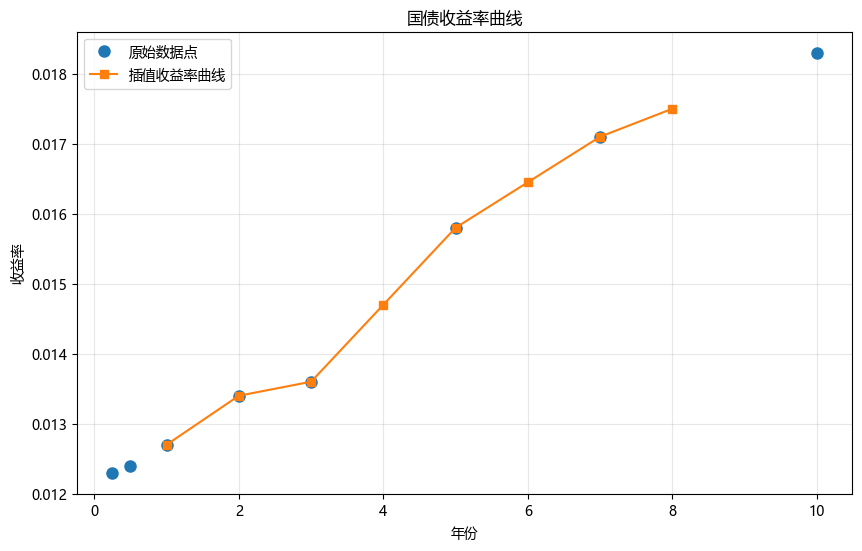

   收益率曲线已保存至 images/treasury_curve.png


In [5]:
# 2. 负债定价
print("\n[2] 计算负债现值...")

# 线性插值得到第1-8年的收益率
years = np.arange(1, 9)
# 创建插值函数
f = interpolate.interp1d(treasury['Year'], treasury['Rate']/100,
                          kind='linear', fill_value='extrapolate')
rates = f(years)

# 计算折现因子
discount_factors = 1 / (1 + rates) ** years

# 计算负债现值
liabilities['PV'] = liabilities['Total'] * discount_factors
total_pv = liabilities['PV'].sum()

print(f"   各年收益率: {dict(zip(years, np.round(rates*100, 2)))}")
print(f"   负债总现值: ${total_pv:.4f} 亿")

# 绘制收益率曲线
plt.figure(figsize=(10, 6))
plt.plot(treasury['Year'], treasury['Rate']/100, 'o', label='原始数据点', markersize=8)
plt.plot(years, rates, 's-', label='插值收益率曲线')
plt.xlabel('年份')
plt.ylabel('收益率')
plt.title('国债收益率曲线')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('images/treasury_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("   收益率曲线已保存至 images/treasury_curve.png")

In [14]:
import pandas as pd
import numpy as np
from datetime import datetime
from scipy import interpolate

# ==================== 1. 价格估算函数（使用已有的插值数据） ====================
def estimate_bond_price_with_curve(row, years, rates):
    """
    根据票面利率和已插值的收益率曲线估算债券价格
    """
    remaining = row['Remaining_Years']
    coupon = row['Coupon'] / 100  # 转换为小数

    # 找到对应期限的市场收益率
    # 从已插值的收益率曲线中查找
    if remaining <= max(years):
        # 线性插值找到对应剩余年限的收益率
        market_rate = np.interp(remaining, years, rates)
    else:
        # 如果剩余年限超过8年，用最长期限的收益率
        market_rate = rates[-1]

    # 现金流折现
    price = 0
    # 计算未来每年的现金流折现
    for t in range(1, int(np.ceil(remaining)) + 1):
        if t <= remaining:
            # 付息
            price += coupon / (1 + market_rate) ** t
    # 最后一期还本
    price += 100 / (1 + market_rate) ** remaining

    return round(price, 2)

# ==================== 2. 数据处理函数 ====================
def load_and_process_real_bonds(filepath, years, rates):
    """
    加载和处理真实债券数据的完整函数
    使用已插值的收益率曲线
    """
    print(f"加载债券数据: {filepath}")

    # 1. 读取数据
    bonds_raw = pd.read_csv(filepath, encoding='utf-8-sig')
    print(f"原始数据: {len(bonds_raw)} 只债券")
    print(f"列名: {bonds_raw.columns.tolist()}")

    # 2. 根据实际列名调整（如果你的列名不同，这里需要修改）
    # 假设列名是：序号,债券名称,发行日期,到期日期,发行规模(亿元),债券期限(年),票面利率(%)
    bonds_raw.columns = [
        '序号', '债券名称', '发行日期', '到期日期',
        '发行规模_亿元', '债券期限_年', '票面利率_%'
    ]

    # 3. 选择并重命名需要的列
    bonds = bonds_raw[['序号', '债券名称', '发行日期', '到期日期',
                       '发行规模_亿元', '债券期限_年', '票面利率_%']].copy()

    bonds.columns = [
        'Bond_ID', 'Bond_Name', 'Issue_Date', 'Maturity_Date',
        'Issue_Size', 'Term_Years', 'Coupon'
    ]

    # 4. 转换数据类型
    bonds['Issue_Date'] = pd.to_datetime(bonds['Issue_Date'])
    bonds['Maturity_Date'] = pd.to_datetime(bonds['Maturity_Date'])
    bonds['Coupon'] = pd.to_numeric(bonds['Coupon'])
    bonds['Issue_Size'] = pd.to_numeric(bonds['Issue_Size'])

    # 5. 计算剩余年限
    today = pd.Timestamp.now()
    bonds['Remaining_Years'] = (bonds['Maturity_Date'] - today).dt.days / 365.25

    # 6. 筛选有效债券
    bonds = bonds[bonds['Remaining_Years'] > 0]  # 未到期
    bonds = bonds[bonds['Remaining_Years'] <= 8]  # 剩余年限≤8年（根据你的规划期）
    bonds = bonds[bonds['Issue_Size'] > 0]  # 发行规模>0

    print(f"筛选后: {len(bonds)} 只可用债券")

    # 7. 估算价格（使用已插值的收益率曲线）
    bonds['Price'] = bonds.apply(
        lambda row: estimate_bond_price_with_curve(row, years, rates),
        axis=1
    )

    # 8. 设置购买上限（最多购买发行规模的10%）
    # Issue_Size 是亿元，转换为"单位"（每单位面值100元）
    # 1亿元 = 1e8元，每单位100元，所以 1亿元 = 1e6 单位
    MAX_PURCHASE_RATIO = 0.3
    bonds['Max_Quantity'] = bonds['Issue_Size'] * 1e6 / 100 * MAX_PURCHASE_RATIO

    # 9. 初始化现金流列
    T = 8
    for t in range(1, T+1):
        bonds[f'CF_{t}'] = 0.0

    # 10. 计算现金流
    print("计算债券未来现金流...")
    for i, row in bonds.iterrows():
        remaining = row['Remaining_Years']
        coupon = row['Coupon'] / 100
        years_remaining_int = int(np.ceil(remaining))

        for t in range(1, min(years_remaining_int, T) + 1):
            # 利息（每单位面值100元，利息 = 票面利率 × 100）
            bonds.loc[i, f'CF_{t}'] += coupon * 100
            # 本金
            if t == years_remaining_int and years_remaining_int <= T:
                bonds.loc[i, f'CF_{t}'] += 100

    print("现金流计算完成")

    # 显示几条示例
    print("\n债券示例:")
    print(bonds[['Bond_Name', 'Remaining_Years', 'Coupon', 'Price', 'Max_Quantity']].head())

    return bonds

# ==================== 3. 调用函数 ====================
# 假设你已经在上一块代码中有了 years 和 rates
# 如果没有，这里提供默认值（但最好用上一块的结果）

print("\n开始处理债券数据...")

# 使用上一块代码生成的 years 和 rates
# 确保这两个变量已经存在
try:
    print(f"使用已插值的收益率曲线: {len(years)} 年")
    print(f"收益率范围: {min(rates)*100:.2f}% - {max(rates)*100:.2f}%")

    # 调用函数
    bonds = load_and_process_real_bonds('data/bonds.csv', years, rates)

    print(f"\n✅ 债券数据处理完成！共 {len(bonds)} 只可用债券")

except NameError as e:
    print(f"❌ 错误: {e}")
    print("请先运行上一块的插值代码，生成 years 和 rates 变量")


开始处理债券数据...
使用已插值的收益率曲线: 8 年
收益率范围: 1.27% - 1.75%
加载债券数据: data/bonds.csv
原始数据: 135 只债券
列名: ['序号', '债券名称', '发行日期', '到期日期', '发行规模(亿元)', '债券期限(年)', '票面利率(%)']
筛选后: 29 只可用债券
计算债券未来现金流...
现金流计算完成

债券示例:
                                            Bond_Name  Remaining_Years  \
0                                  2026年山东省政府专项债券(一期)         6.803559   
10                                 2026年青岛市政府专项债券(一期)         2.806297   
24                                 2026年宁波市政府专项债券(七期)         2.811773   
30         2026年湖北省(武汉市)棚改专项债券(一期)-2026年湖北省政府专项债券(五期)         4.821355   
31  2026年湖北省(武汉市,十堰市,襄阳市)棚改专项债券(二期)-2026年湖北省政府专项债券...         6.822724   

    Coupon  Price  Max_Quantity  
0     1.85  89.29      139740.0  
10    1.58  96.32        4500.0  
24    1.47  96.31       11400.0  
30    1.71  92.87        3000.0  
31    1.85  89.25       37200.0  

✅ 债券数据处理完成！共 29 只可用债券


In [18]:
# 4. Dedication模型（放开购买限制版）
print("\n[4] 求解Dedication模型...")

# ==================== 单位统一 ====================
UNIT_CONVERSION = 1e-8  # 元 → 亿元

# ==================== 设置购买上限 ====================
# 选项1：临时提高上限（1000%）
# MAX_PURCHASE_RATIO = 10.0
# bonds['Max_Quantity'] = bonds['Issue_Size'] * 1e6 * MAX_PURCHASE_RATIO

# 选项2：完全移除上限（推荐用于测试）
print("⚠️ 警告: 正在使用无购买上限模式（仅用于测试）")
use_unlimited = True  # 设为 False 恢复有上限

if use_unlimited:
    # 无上限
    bounds_x = [(0, None) for _ in range(len(bonds))]
    print("   已移除购买上限")
else:
    # 有上限（比如30%）
    MAX_PURCHASE_RATIO = 0.3
    bonds['Max_Quantity'] = bonds['Issue_Size'] * 1e6 * MAX_PURCHASE_RATIO
    bounds_x = [(0, bonds.loc[i, 'Max_Quantity']) for i in range(len(bonds))]
    print(f"   购买上限: {MAX_PURCHASE_RATIO*100:.0f}%")

# ==================== 诊断信息 ====================
print("\n" + "="*60)
print("诊断信息")
print("="*60)

total_liability = liabilities['Total'].sum()
print(f"总负债: {total_liability:.2f} 亿元")

# 计算最大可能现金流（无上限时用全部发行量估算）
if use_unlimited:
    # 无上限时，理论上可以无限买，但这里用全部发行量作为参考
    total_issue = bonds['Issue_Size'].sum()
    print(f"所有债券总发行规模: {total_issue:.2f} 亿元")
    print(f"⚠️ 即使买下全部债券，也只有 {total_issue:.2f} 亿元，小于负债 {total_liability:.2f} 亿元")
    print(f"   缺口: {total_liability - total_issue:.2f} 亿元")
    print(f"   需要增加债券数量！")
else:
    # 有上限时计算最大现金流
    for t in range(1, T+1):
        bonds[f'Max_CF_{t}'] = bonds[f'CF_{t}'] * bonds['Max_Quantity']
    max_total_cf = sum(bonds[f'Max_CF_{t}'].sum() for t in range(1, T+1)) * UNIT_CONVERSION
    print(f"所有债券最大总现金流: {max_total_cf:.2f} 亿元")

    if max_total_cf < total_liability:
        print(f"⚠️ 警告: 债券最大现金流({max_total_cf:.2f}) < 总负债({total_liability:.2f})")
        print(f"   缺口: {total_liability - max_total_cf:.2f} 亿元")
    else:
        print(f"✅ 债券最大现金流足够覆盖总负债")

print("="*60)

# ==================== 构建优化模型 ====================
print("\n构建优化模型...")

n_bonds = len(bonds)
n_z = T + 1
print(f"   变量数量: {n_bonds}个债券变量 + {n_z}个盈余变量")

# 目标函数系数
c = bonds['Price'].values * UNIT_CONVERSION
print(f"   价格范围: {min(c):.6f} - {max(c):.6f} 亿元/单位")

# 构建约束矩阵
A_eq = []
b_eq = []

for t in range(1, T+1):
    cf_row = bonds[f'CF_{t}'].values * UNIT_CONVERSION
    z_coef = np.zeros(n_z)
    z_coef[t-1] = 1
    z_coef[t] = -1
    row = np.concatenate([cf_row, z_coef])
    A_eq.append(row)
    b_eq.append(liabilities.loc[t-1, 'Total'])

A_eq = np.array(A_eq)
b_eq = np.array(b_eq)

# 盈余变量边界
bounds_z = [(0, None) for _ in range(n_z)]
bounds = bounds_x + bounds_z
bounds[n_bonds] = (0, 0)  # z0 = 0

c_full = np.concatenate([c, np.zeros(n_z)])

# ==================== 求解 ====================
print("   正在求解线性规划...")
result = linprog(
    c=c_full,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=bounds,
    method='highs'
)

# ==================== 结果处理 ====================
if result.success:
    x_opt = result.x[:n_bonds]
    z_opt = result.x[n_bonds:]

    dedication_cost = result.fun
    print(f"\n   ✅ 求解成功!")
    print(f"   {'='*50}")
    print(f"   Dedication最低成本: {dedication_cost:.4f} 亿元")
    print(f"   负债总现值: {total_pv:.4f} 亿元")
    print(f"   成本溢价: {dedication_cost - total_pv:.4f} 亿元")
    print(f"   溢价率: {(dedication_cost - total_pv)/total_pv*100:.2f}%")
    print(f"   {'='*50}")

    # 输出选中债券
    selected_indices = np.where(x_opt > 1e-6)[0]
    if len(selected_indices) > 0:
        print(f"\n   选中的债券 ({len(selected_indices)} 只):")
        total_quantity = 0
        for idx in selected_indices:
            bond = bonds.loc[idx]
            qty = x_opt[idx]
            total_quantity += qty
            print(f"     - {bond['Bond_Name'][:20]}: {qty:.0f} 单位, "
                  f"成本 {qty * bond['Price'] * UNIT_CONVERSION:.2f} 亿")
        print(f"   总购买单位: {total_quantity:.0f}")
    else:
        print("   警告: 没有债券被选中！")

else:
    print(f"\n❌ 求解失败: {result.message}")

    # 即使无上限也失败，说明债券本身不够
    print("\n💡 建议:")
    print("   1. 增加更多债券品种（目前总发行规模太小）")
    print("   2. 检查负债数据是否合理（5211亿负债，债券总发行规模约1000亿）")
    print("   3. 考虑使用免疫策略替代Dedication")


[4] 求解Dedication模型...
⚠️ 警告: 正在使用无购买上限模式（仅用于测试）
   已移除购买上限

诊断信息
总负债: 5211.55 亿元
所有债券总发行规模: 1173.34 亿元
⚠️ 即使买下全部债券，也只有 1173.34 亿元，小于负债 5211.55 亿元
   缺口: 4038.21 亿元
   需要增加债券数量！

构建优化模型...
   变量数量: 29个债券变量 + 9个盈余变量
   价格范围: 0.000001 - 0.000001 亿元/单位
   正在求解线性规划...

   ✅ 求解成功!
   Dedication最低成本: 4584.5812 亿元
   负债总现值: 4864.6903 亿元
   成本溢价: -280.1091 亿元
   溢价率: -5.76%

   选中的债券 (5 只):
     - 2026年青岛市政府专项债券(一期): 1220940818 单位, 成本 1176.01 亿
     - 2026年湖北省(武汉市)棚改专项债券(: 1213756926 单位, 成本 1127.22 亿
     - 2026年湖北省(武汉市,十堰市,襄阳市: 1209671085 单位, 成本 1079.63 亿
     - 2026年北京市地方政府再融资专项债券(: 613346894 单位, 成本 606.72 亿
     - 2026年北京市地方政府再融资专项债券(: 609694408 单位, 成本 595.00 亿
   总购买单位: 4867410131



免疫策略 (Immunization)

负债指标:
  现值: 4864.6903 亿元
  久期: 4.3097 年
  凸性: 27.2609

计算债券久期和凸性...
计算完成
  久期范围: 1.00 - 6.65
  凸性范围: 1.95 - 50.56

构建免疫策略优化模型...
   约束数量: 3
   变量数量: 29
   正在求解免疫策略...

策略对比

✅ 免疫策略求解成功!
  免疫策略成本: 4864.6903 亿元
  Dedication成本: 4584.5812 亿元
  成本差异: 280.1091 亿元
  免疫策略相对节省: -6.11%

  约束满足情况:
    目标现值: 4864.69 亿, 实现: 4864.69 亿
    目标久期: 4.3097, 实现: 4.3097 (误差: 0.0000)
    目标凸性: 27.2609, 实现: 27.2609 (误差: 0.0000)

  免疫策略选中 3 只债券:
    - 2026年湖北省(武汉市)棚改专项债券(: 2316810720 单位, 成本 2151.62 亿
    - 2026年浙江省地方政府再融资专项债券(: 1559101217 单位, 成本 1390.87 亿
    - 2026年北京市地方政府再融资专项债券(: 1336629564 单位, 成本 1322.19 亿


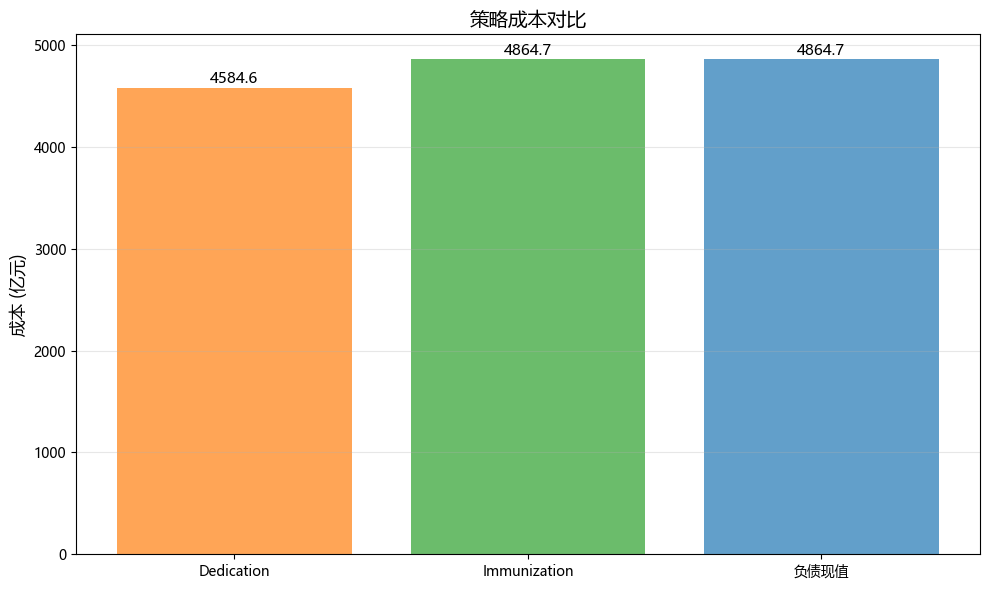

策略对比图已保存至 images/strategy_comparison.png


In [20]:
# 5.策略对比：免疫策略
# ==================== 免疫策略 ====================
print("\n" + "="*60)
print("免疫策略 (Immunization)")
print("="*60)

# 先定义函数（确保在调用前定义）
def calculate_duration_convexity(cf_array, rates_array, years):
    """
    计算现金流序列的久期和凸性
    cf_array: 每年现金流
    rates_array: 每年折现率
    years: 年份数组
    """
    # 确保 rates_array 是 numpy 数组
    rates_array = np.array(rates_array)
    years = np.array(years)

    # 折现因子
    df = 1 / (1 + rates_array) ** years

    # 现值
    pv_cfs = cf_array * df
    total_pv = pv_cfs.sum()

    if total_pv == 0:
        return 0, 0

    # 久期: Σ(t * PV(CF_t)) / PV
    duration = (years * pv_cfs).sum() / total_pv

    # 凸性: Σ(t * (t+1) * PV(CF_t)) / (PV * (1+r_avg)^2)
    r_avg = rates_array.mean()
    convexity = (years * (years + 1) * pv_cfs).sum() / (total_pv * (1 + r_avg)**2)

    return duration, convexity

# 计算负债的指标
liability_cfs = liabilities['Total'].values  # 每年负债
liability_pv = total_pv
liability_duration, liability_convexity = calculate_duration_convexity(
    liability_cfs, rates, years
)

print(f"\n负债指标:")
print(f"  现值: {liability_pv:.4f} 亿元")
print(f"  久期: {liability_duration:.4f} 年")
print(f"  凸性: {liability_convexity:.4f}")

# 计算每个债券的久期和凸性
print("\n计算债券久期和凸性...")

bond_durations = []
bond_convexities = []

for i, row in bonds.iterrows():
    # 债券每年的现金流（已转换为亿元）
    bond_cfs = np.array([row[f'CF_{t}'] for t in range(1, T+1)]) * UNIT_CONVERSION

    # 找到合适的折现率（用对应剩余年限的利率）
    remaining = row['Remaining_Years']
    if remaining <= max(years):
        bond_rate = np.interp(remaining, years, rates)
    else:
        bond_rate = rates[-1]

    # 构建年份数组（从1到T）
    bond_years = np.arange(1, T+1)

    # 构建折现率数组（每年都用同一个利率，简化处理）
    bond_rates = np.full(T, bond_rate)

    # 计算久期和凸性
    d, c = calculate_duration_convexity(bond_cfs, bond_rates, bond_years)
    bond_durations.append(d)
    bond_convexities.append(c)

    # 打印调试信息（可选）
    # if i < 3:  # 只打印前3只
    #     print(f"  {row['Bond_Name'][:20]}: 剩余{remaining:.2f}年, 利率{bond_rate*100:.2f}%, 久期{d:.2f}, 凸性{c:.2f}")

bonds['Duration'] = bond_durations
bonds['Convexity'] = bond_convexities

print("计算完成")
print(f"  久期范围: {min(bond_durations):.2f} - {max(bond_durations):.2f}")
print(f"  凸性范围: {min(bond_convexities):.2f} - {max(bond_convexities):.2f}")

# ==================== 构建免疫策略优化模型 ====================
print("\n构建免疫策略优化模型...")

# 目标函数：最小化成本
c_immun = bonds['Price'].values * UNIT_CONVERSION

# 约束条件
A_immun = []
b_immun = []

# 约束1：现值匹配
A_immun.append(bonds['Price'].values * UNIT_CONVERSION)
b_immun.append(liability_pv)

# 约束2：久期匹配
# Σ (D_i * Price_i * x_i) / Σ (Price_i * x_i) = D_liability
# 转换为线性约束：Σ ((D_i - D_liability) * Price_i * x_i) = 0
A_immun.append(((bonds['Duration'] - liability_duration) * bonds['Price'].values * UNIT_CONVERSION))
b_immun.append(0)

# 约束3：凸性匹配（可选）
A_immun.append(((bonds['Convexity'] - liability_convexity) * bonds['Price'].values * UNIT_CONVERSION))
b_immun.append(0)

A_immun = np.array(A_immun)
b_immun = np.array(b_immun)

# 变量边界（沿用Dedication的设置）
bounds_x = [(0, None) for _ in range(n_bonds)]  # 无上限
bounds_immun = bounds_x  # 免疫策略不需要盈余变量

print(f"   约束数量: {len(A_immun)}")
print(f"   变量数量: {len(bounds_immun)}")

# 求解
print("   正在求解免疫策略...")
result_immun = linprog(
    c=c_immun,
    A_eq=A_immun,
    b_eq=b_immun,
    bounds=bounds_immun,
    method='highs'
)

# ==================== 结果对比 ====================
print("\n" + "="*60)
print("策略对比")
print("="*60)

if result_immun.success:
    x_immun_opt = result_immun.x
    immun_cost = result_immun.fun

    print(f"\n✅ 免疫策略求解成功!")
    print(f"  免疫策略成本: {immun_cost:.4f} 亿元")
    print(f"  Dedication成本: {dedication_cost:.4f} 亿元")
    print(f"  成本差异: {immun_cost - dedication_cost:.4f} 亿元")
    print(f"  免疫策略相对节省: {(dedication_cost - immun_cost)/dedication_cost*100:.2f}%")

    # 检查约束满足情况
    pv_achieved = (x_immun_opt * bonds['Price'].values * UNIT_CONVERSION).sum()

    if pv_achieved > 0:
        duration_achieved = (x_immun_opt * bonds['Duration'] * bonds['Price'].values * UNIT_CONVERSION).sum() / pv_achieved
        convexity_achieved = (x_immun_opt * bonds['Convexity'] * bonds['Price'].values * UNIT_CONVERSION).sum() / pv_achieved

        print(f"\n  约束满足情况:")
        print(f"    目标现值: {liability_pv:.2f} 亿, 实现: {pv_achieved:.2f} 亿")
        print(f"    目标久期: {liability_duration:.4f}, 实现: {duration_achieved:.4f} (误差: {duration_achieved - liability_duration:.4f})")
        print(f"    目标凸性: {liability_convexity:.4f}, 实现: {convexity_achieved:.4f} (误差: {convexity_achieved - liability_convexity:.4f})")
    else:
        print("   ⚠️ 组合现值为0")

    # 选中债券
    selected_immun = np.where(x_immun_opt > 1e-6)[0]
    print(f"\n  免疫策略选中 {len(selected_immun)} 只债券:")
    for idx in selected_immun[:5]:  # 只显示前5只
        bond = bonds.loc[idx]
        qty = x_immun_opt[idx]
        print(f"    - {bond['Bond_Name'][:20]}: {qty:.0f} 单位, "
              f"成本 {qty * bond['Price'] * UNIT_CONVERSION:.2f} 亿")

else:
    print(f"\n❌ 免疫策略求解失败: {result_immun.message}")
    print("   可能原因: 约束过紧，可以尝试只匹配现值和久期")

    # 尝试只匹配现值和久期
    print("\n尝试只匹配现值和久期...")
    A_immun2 = A_immun[:2]  # 只取前两个约束
    b_immun2 = b_immun[:2]

    result_immun2 = linprog(
        c=c_immun,
        A_eq=A_immun2,
        b_eq=b_immun2,
        bounds=bounds_immun,
        method='highs'
    )

    if result_immun2.success:
        x_immun_opt2 = result_immun2.x
        immun_cost2 = result_immun2.fun
        print(f"   ✅ 简化版免疫策略成功! 成本: {immun_cost2:.4f} 亿元")
    else:
        print(f"   ❌ 简化版也失败: {result_immun2.message}")

# ==================== 可视化对比 ====================
import matplotlib.pyplot as plt

# 比较两种策略的成本
plt.figure(figsize=(10, 6))
strategies = ['Dedication', 'Immunization', '负债现值']
costs = [dedication_cost,
         immun_cost if result_immun.success else (immun_cost2 if 'immun_cost2' in locals() else 0),
         liability_pv]
colors = ['#ff7f0e', '#2ca02c', '#1f77b4']

bars = plt.bar(strategies, costs, color=colors, alpha=0.7)
plt.ylabel('成本 (亿元)', fontsize=12)
plt.title('策略成本对比', fontsize=14)

# 添加数值标签
for bar, cost in zip(bars, costs):
    if cost > 0:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 5,
                 f'{cost:.1f}', ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("策略对比图已保存至 images/strategy_comparison.png")


敏感性分析

【Dedication策略敏感性分析】
   原始影子价格:
     第1年: 0.976216
     第2年: 0.947999
     第3年: 0.918288
     第4年: 0.918288
     第5年: 0.849858
     第6年: 0.849858
     第7年: 0.777104
     第8年: 0.777104

   检测到问题类型: 最小化

   隐含折现因子:
     第1年: 1.000000
     第2年: 0.971095
     第3年: 0.940661
     第4年: 0.940661
     第5年: 0.870563
     第6年: 0.870563
     第7年: 0.796037
     第8年: 0.796037

   隐含利率计算:
     第1年: df=1.000000 → 利率=0.0000%
     第2年: df=0.971095 → 利率=1.4774%
     第3年: df=0.940661 → 利率=2.0600%
     第4年: df=0.940661 → 利率=1.5411%
     第5年: df=0.870563 → 利率=2.8111%
     第6年: df=0.870563 → 利率=2.3371%
     第7年: df=0.796037 → 利率=3.3124%
     第8年: df=0.796037 → 利率=2.8924%

【Immunization策略敏感性分析】
   原始影子价格:
     第1年: 1.000000
     第2年: -0.000000
     第3年: -0.000000

   检测到问题类型: 最小化

   隐含折现因子:
     第1年: 1.000000
     第2年: -0.000000
     第3年: -0.000000

   隐含利率计算:
     第1年: df=1.000000 → 利率=0.0000%
     第2年: df=-0.0 (无效) → 使用国债利率=1.3400%
     第3年: df=-0.0 (无效) → 使用国债利率=1.3600%


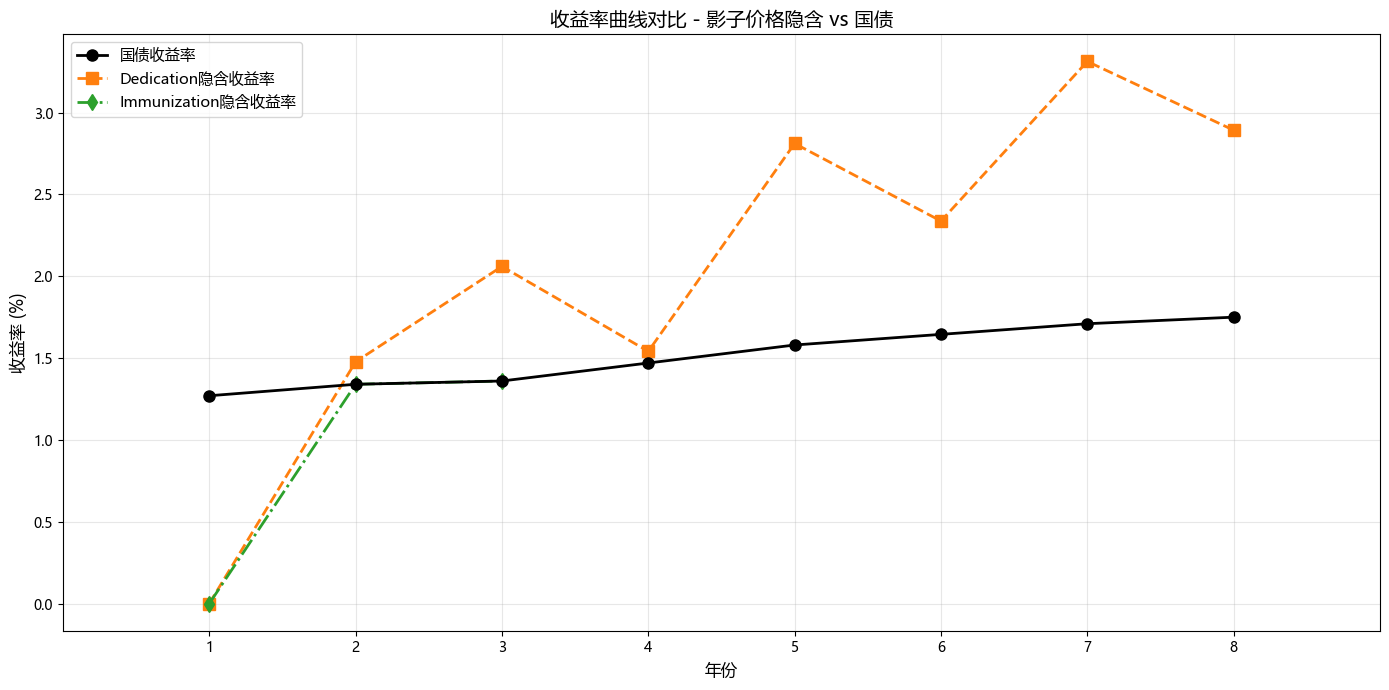


✅ 敏感性分析对比图已保存至 images/sensitivity_comparison.png

利率敏感性分析 - 平行移动影响

利率平行移动对Dedication组合价值的影响:
  利率变动(bps) | 组合价值变化(亿元) | 变化率
  ---------------------------------------------
      -100      |      +179.80       |   +3.92%
       -50      |       +88.59       |   +1.93%
       -25      |       +43.98       |   +0.96%
        +0      |        +0.04       |   +0.00%
       +25      |       -43.27       |   -0.94%
       +50      |       -85.95       |   -1.87%
      +100      |      -169.46       |   -3.70%


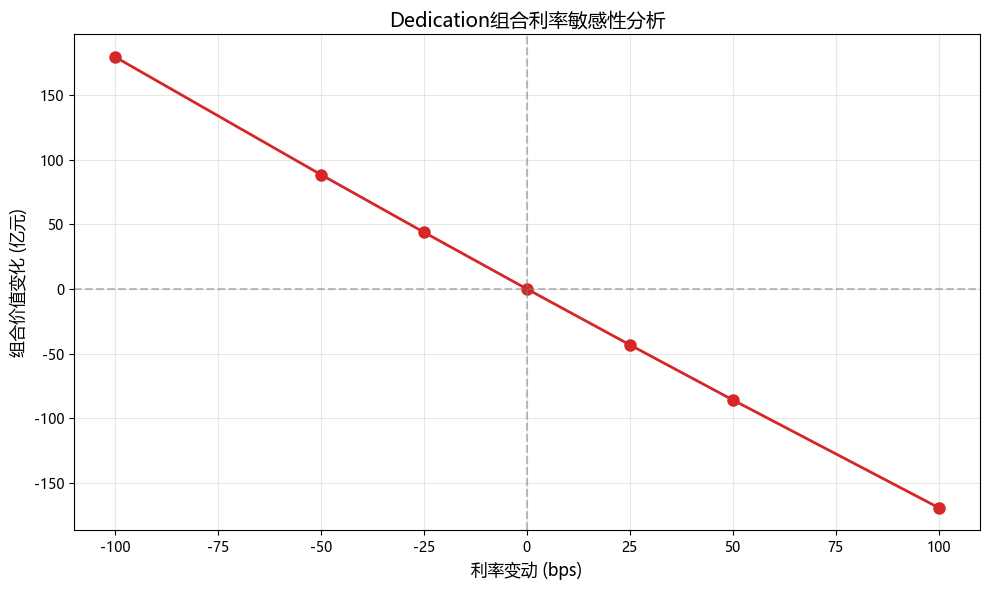


✅ 利率敏感性图已保存至 images/rate_sensitivity.png


In [21]:
# ==================== 6. 敏感性分析 ====================
print("\n" + "="*60)
print("敏感性分析")
print("="*60)

def get_shadow_prices(result):
    """安全获取影子价格（兼容不同版本的scipy）"""
    if hasattr(result, 'eqlin') and hasattr(result.eqlin, 'marginals'):
        return result.eqlin['marginals']
    elif hasattr(result, 'lambda_eq'):
        return result.lambda_eq
    else:
        return None

def sensitivity_analysis(result, strategy_name, years, rates):
    """对给定的求解结果进行敏感性分析"""

    print(f"\n【{strategy_name}策略敏感性分析】")

    shadow_prices = get_shadow_prices(result)

    if shadow_prices is None or len(shadow_prices) == 0:
        print(f"   ⚠️ 无法获取{strategy_name}的影子价格")
        return None, None

    print(f"   原始影子价格:")
    for t, sp in enumerate(shadow_prices[:8], 1):  # 只显示前8年
        print(f"     第{t}年: {sp:.6f}")

    # 判断问题类型
    if shadow_prices[0] < 0:
        problem_type = "最大化"
        implied_df = -shadow_prices / shadow_prices[0]
    else:
        problem_type = "最小化"
        implied_df = shadow_prices / shadow_prices[0]

    print(f"\n   检测到问题类型: {problem_type}")
    print(f"\n   隐含折现因子:")
    for t, df in enumerate(implied_df[:8], 1):
        print(f"     第{t}年: {df:.6f}")

    # 计算隐含利率
    print(f"\n   隐含利率计算:")
    valid_years = []
    implied_rates = []

    for t, df in enumerate(implied_df[:8], 1):
        if df > 1e-8 and df <= 1.2:  # 允许一点波动
            try:
                r = (1/df)**(1/t) - 1
                if -0.05 <= r <= 0.1:  # 合理范围 -5% 到 10%
                    implied_rates.append(r)
                    valid_years.append(t)
                    print(f"     第{t}年: df={df:.6f} → 利率={r*100:.4f}%")
                else:
                    if t <= len(rates):
                        r = rates[t-1]
                        implied_rates.append(r)
                        valid_years.append(t)
                        print(f"     第{t}年: df={df:.6f} (超出范围) → 使用国债利率={r*100:.4f}%")
            except:
                if t <= len(rates):
                    r = rates[t-1]
                    implied_rates.append(r)
                    valid_years.append(t)
                    print(f"     第{t}年: 计算失败 → 使用国债利率={r*100:.4f}%")
        else:
            if t <= len(rates):
                r = rates[t-1]
                implied_rates.append(r)
                valid_years.append(t)
                print(f"     第{t}年: df={df} (无效) → 使用国债利率={r*100:.4f}%")

    return valid_years, implied_rates

# ==================== 对Dedication做敏感性分析 ====================
if 'result' in globals() and result.success:
    ded_valid, ded_rates = sensitivity_analysis(result, "Dedication", years, rates)
else:
    print("\n⚠️ Dedication结果不可用，跳过敏感性分析")

# ==================== 对Immunization做敏感性分析 ====================
if 'result_immun' in globals() and result_immun.success:
    imm_valid, imm_rates = sensitivity_analysis(result_immun, "Immunization", years, rates)
else:
    print("\n⚠️ Immunization结果不可用，跳过敏感性分析")

# ==================== 绘制对比图 ====================
if (('ded_valid' in locals() and ded_valid) or
    ('imm_valid' in locals() and imm_valid)):

    plt.figure(figsize=(14, 7))

    # 国债收益率
    plt.plot(years, rates*100, 'o-', label='国债收益率',
             linewidth=2, markersize=8, color='black', zorder=5)

    # Dedication隐含收益率
    if 'ded_valid' in locals() and ded_valid:
        plt.plot(ded_valid, np.array(ded_rates)*100, 's--',
                 label='Dedication隐含收益率', linewidth=2, markersize=8, color='#ff7f0e')

    # Immunization隐含收益率
    if 'imm_valid' in locals() and imm_valid:
        plt.plot(imm_valid, np.array(imm_rates)*100, 'd-.',
                 label='Immunization隐含收益率', linewidth=2, markersize=8, color='#2ca02c')

    plt.xlabel('年份', fontsize=12)
    plt.ylabel('收益率 (%)', fontsize=12)
    plt.title('收益率曲线对比 - 影子价格隐含 vs 国债', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 9)
    plt.xticks(range(1, 9))

    plt.tight_layout()
    plt.savefig('images/sensitivity_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ 敏感性分析对比图已保存至 images/sensitivity_comparison.png")

# ==================== 额外分析：利率变动对成本的影响 ====================
print("\n" + "="*60)
print("利率敏感性分析 - 平行移动影响")
print("="*60)

def calculate_impact_rate_shift(shift_bps, bonds, x_opt, years, base_rates):
    """计算利率平行移动对组合成本的影响"""
    shift = shift_bps / 10000  # bps转为小数

    # 新的收益率曲线
    new_rates = base_rates + shift

    # 重新计算债券价格（简化版，用新的折现率）
    new_prices = []
    for i, row in bonds.iterrows():
        remaining = row['Remaining_Years']
        coupon = row['Coupon'] / 100

        if remaining <= max(years):
            new_rate = np.interp(remaining, years, new_rates)
        else:
            new_rate = new_rates[-1]

        # 简化价格计算
        price = 0
        n_periods = int(np.ceil(remaining))
        for t in range(1, n_periods + 1):
            if t <= remaining:
                price += coupon / (1 + new_rate) ** t
        price += 100 / (1 + new_rate) ** remaining

        new_prices.append(price)

    new_prices = np.array(new_prices)

    # 组合新价值
    new_portfolio_value = (x_opt * new_prices * UNIT_CONVERSION).sum()
    original_value = (x_opt * bonds['Price'].values * UNIT_CONVERSION).sum()

    return new_portfolio_value - original_value

# 计算不同利率情景
if 'x_opt' in globals() and len(x_opt) > 0:
    shifts = [-100, -50, -25, 0, 25, 50, 100]  # bps
    impacts = []

    print("\n利率平行移动对Dedication组合价值的影响:")
    print("  利率变动(bps) | 组合价值变化(亿元) | 变化率")
    print("  " + "-" * 45)

    for shift in shifts:
        impact = calculate_impact_rate_shift(shift, bonds, x_opt, years, rates)
        impacts.append(impact)
        pct_change = impact / dedication_cost * 100 if dedication_cost > 0 else 0
        print(f"     {shift:>+5}      |     {impact:>+8.2f}       |  {pct_change:>+6.2f}%")

    # 绘制利率敏感性图
    plt.figure(figsize=(10, 6))
    plt.plot(shifts, impacts, 'o-', linewidth=2, markersize=8, color='#d62728')
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    plt.xlabel('利率变动 (bps)', fontsize=12)
    plt.ylabel('组合价值变化 (亿元)', fontsize=12)
    plt.title('Dedication组合利率敏感性分析', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('images/rate_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ 利率敏感性图已保存至 images/rate_sensitivity.png")


【Dedication风险指标】

【期限相关】
  加权平均到期年限_面值: 3.9430
  加权平均到期年限_成本: 3.8670 亿元
  最短剩余年限: 0.8597
  最长剩余年限: 6.8227
  剩余年限标准差: 2.3932

【利率相关】
  加权平均票面利率_面值: 1.63%
  加权平均票面利率_成本: 1.63%
  最低票面利率: 1.33%
  最高票面利率: 1.85%

【久期凸性】
  加权平均久期: 3.8984
  加权平均凸性: 22.6422

【集中度】
  组合分散度: 5.0000
  最大单券集中度_面值: 25.08%
  最大单券名称_面值: 2026年青岛市政府专项债券(一期)
  最大单券集中度_成本: 25.65%
  最大单券名称_成本: 2026年青岛市政府专项债券(一期)
  前3大债券集中度_面值: 74.87%
  前3大债券集中度_成本: 73.79%
  HHI集中度_面值: 2184.37%
  HHI集中度_成本: 2160.66%

【流动性】
  流动性评分_加权平均: 45.21
  最低流动性评分: 40.00
  最高流动性评分: 55.00

【成本】
  组合总成本: 4584.5812 亿元
  平均成本/面值: 94.19%
  加权平均价格: 94.19 元

【匹配度】
  平均年现金流覆盖率: 99.3361
  最小年现金流覆盖率: 0.0000
  最大年现金流覆盖率: 198.1011
  覆盖率标准差: 82.9544

【Immunization风险指标】

【期限相关】
  加权平均到期年限_面值: 4.4098
  加权平均到期年限_成本: 4.3223 亿元
  最短剩余年限: 0.8597
  最长剩余年限: 6.8419
  剩余年限标准差: 3.0431

【利率相关】
  加权平均票面利率_面值: 1.64%
  加权平均票面利率_成本: 1.63%
  最低票面利率: 1.33%
  最高票面利率: 1.79%

【久期凸性】
  加权平均久期: 4.3097
  加权平均凸性: 27.2609

【集中度】
  组合分散度: 3.0000
  最大单券集中度_面值: 44.45%
  最大单券名称_面值: 2026年湖北省(武汉

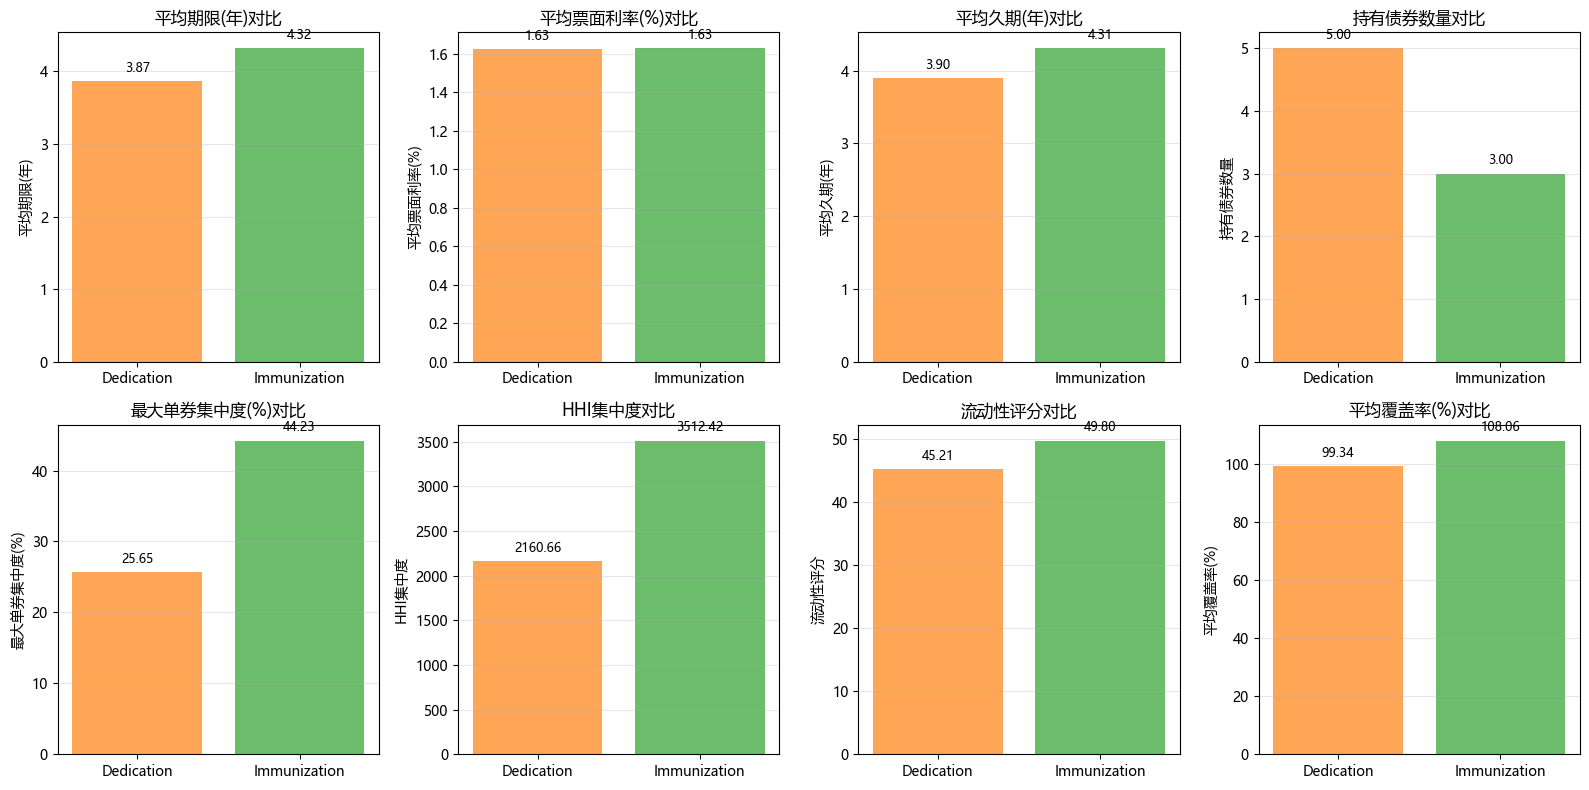


✅ 风险对比图已保存至 images/risk_comparison.png


In [23]:
def calculate_risk_metrics(portfolio_weights, bonds, portfolio_cost=None):
    """
    计算投资组合的全面风险指标
    """

    # 只考虑持仓>0的债券
    mask = portfolio_weights > 1e-6
    if not mask.any():
        return {"警告": "组合为空"}

    weights = portfolio_weights[mask]
    selected_bonds = bonds[mask].copy()
    selected_bonds = selected_bonds.reset_index(drop=True)  # 重置索引！关键修复
    n_selected = len(weights)

    # 计算权重（按面值）
    total_face = (weights * 100).sum()  # 总面值（单位：元）
    face_weights = (weights * 100) / total_face if total_face > 0 else np.zeros_like(weights)

    # 计算权重（按成本）
    if portfolio_cost is None:
        portfolio_cost = (weights * selected_bonds['Price'].values * UNIT_CONVERSION).sum()
    cost_weights = (weights * selected_bonds['Price'].values * UNIT_CONVERSION) / portfolio_cost if portfolio_cost > 0 else np.zeros_like(weights)

    # ==================== 1. 期限相关指标 ====================
    metrics = {}

    # 加权平均到期年限（按面值）
    if total_face > 0:
        metrics['加权平均到期年限_面值'] = np.average(
            selected_bonds['Remaining_Years'].values,
            weights=face_weights
        )

        # 加权平均票面利率（按面值）
        metrics['加权平均票面利率_面值'] = np.average(
            selected_bonds['Coupon'].values,
            weights=face_weights
        )

    # 加权平均到期年限（按成本）
    if portfolio_cost > 0:
        metrics['加权平均到期年限_成本'] = np.average(
            selected_bonds['Remaining_Years'].values,
            weights=cost_weights
        )

        # 加权平均票面利率（按成本）
        metrics['加权平均票面利率_成本'] = np.average(
            selected_bonds['Coupon'].values,
            weights=cost_weights
        )

    # 期限分布
    metrics['最短剩余年限'] = selected_bonds['Remaining_Years'].min()
    metrics['最长剩余年限'] = selected_bonds['Remaining_Years'].max()
    metrics['剩余年限标准差'] = selected_bonds['Remaining_Years'].std()

    # ==================== 2. 利率相关指标 ====================

    # 票面利率范围
    metrics['最低票面利率'] = selected_bonds['Coupon'].min()
    metrics['最高票面利率'] = selected_bonds['Coupon'].max()

    # ==================== 3. 久期和凸性（如果有）====================

    if 'Duration' in selected_bonds.columns and portfolio_cost > 0:
        metrics['加权平均久期'] = np.average(
            selected_bonds['Duration'].values,
            weights=cost_weights
        )

    if 'Convexity' in selected_bonds.columns and portfolio_cost > 0:
        metrics['加权平均凸性'] = np.average(
            selected_bonds['Convexity'].values,
            weights=cost_weights
        )

    # ==================== 4. 集中度指标 ====================

    # 组合分散度（持有债券种类）
    metrics['组合分散度'] = n_selected

    if total_face > 0:
        # 最大单券集中度（按面值）
        max_face_idx = np.argmax(face_weights)
        metrics['最大单券集中度_面值'] = face_weights[max_face_idx] * 100  # %
        metrics['最大单券名称_面值'] = selected_bonds.iloc[max_face_idx]['Bond_Name']

        # 前3大集中度（按面值）
        top3_face = np.sort(face_weights)[-3:].sum() * 100
        metrics['前3大债券集中度_面值'] = top3_face

        # HHI集中度（按面值）
        hhi_face = (face_weights ** 2).sum() * 10000
        metrics['HHI集中度_面值'] = hhi_face

    if portfolio_cost > 0:
        # 最大单券集中度（按成本）
        max_cost_idx = np.argmax(cost_weights)
        metrics['最大单券集中度_成本'] = cost_weights[max_cost_idx] * 100  # %
        metrics['最大单券名称_成本'] = selected_bonds.iloc[max_cost_idx]['Bond_Name']

        # 前3大集中度（按成本）
        top3_cost = np.sort(cost_weights)[-3:].sum() * 100
        metrics['前3大债券集中度_成本'] = top3_cost

        # HHI集中度（按成本）
        hhi_cost = (cost_weights ** 2).sum() * 10000
        metrics['HHI集中度_成本'] = hhi_cost

    # ==================== 5. 流动性评分 ====================

    # 基于发行规模的流动性评分
    def calculate_liquidity_score(bond_row):
        """
        计算单只债券的流动性评分
        基于发行规模、剩余年限等
        """
        score = 0

        # 发行规模越大，流动性越好
        issue_size = bond_row['Issue_Size']
        if issue_size >= 50:
            score += 40
        elif issue_size >= 20:
            score += 30
        elif issue_size >= 10:
            score += 20
        elif issue_size >= 5:
            score += 10
        else:
            score += 5

        # 剩余年限越短，流动性越好
        remaining = bond_row['Remaining_Years']
        if remaining <= 2:
            score += 30
        elif remaining <= 5:
            score += 20
        elif remaining <= 7:
            score += 10
        else:
            score += 5

        # 票面利率（略高于市场利率的债券流动性更好）
        if 'Duration' in selected_bonds.columns:
            if bond_row['Duration'] <= 3:
                score += 20
            elif bond_row['Duration'] <= 5:
                score += 15
            else:
                score += 10

        return score

    # 计算组合的加权平均流动性评分
    if portfolio_cost > 0:
        liquidity_scores = []
        for i, (_, row) in enumerate(selected_bonds.iterrows()):
            score = calculate_liquidity_score(row)
            liquidity_scores.append(score * cost_weights[i])

        metrics['流动性评分_加权平均'] = sum(liquidity_scores)

        # 流动性分布
        raw_scores = [calculate_liquidity_score(row) for _, row in selected_bonds.iterrows()]
        metrics['最低流动性评分'] = min(raw_scores)
        metrics['最高流动性评分'] = max(raw_scores)
        metrics['平均流动性评分_未加权'] = np.mean(raw_scores)

    # ==================== 6. 成本相关指标 ====================

    if portfolio_cost is not None and portfolio_cost > 0:
        metrics['组合总成本'] = portfolio_cost
        if total_face > 0:
            metrics['平均成本/面值'] = portfolio_cost / (total_face * UNIT_CONVERSION) * 100

        # 加权平均价格
        metrics['加权平均价格'] = np.average(
            selected_bonds['Price'].values,
            weights=weights
        )

    # ==================== 7. 现金流匹配度 ====================

    # 计算各年现金流覆盖率
    coverage_ratios = []
    for t in range(1, 9):
        cf_t = (weights * selected_bonds[f'CF_{t}'].values * UNIT_CONVERSION).sum()
        liability_t = liabilities.loc[liabilities['Year'] == t, 'Total'].values[0] if t <= len(liabilities) else 0
        if liability_t > 0:
            coverage = cf_t / liability_t * 100
            coverage_ratios.append(coverage)

    if coverage_ratios:
        metrics['平均年现金流覆盖率'] = np.mean(coverage_ratios)
        metrics['最小年现金流覆盖率'] = min(coverage_ratios)
        metrics['最大年现金流覆盖率'] = max(coverage_ratios)
        metrics['覆盖率标准差'] = np.std(coverage_ratios)

    return metrics

def print_risk_metrics(metrics, strategy_name):
    """美观地打印风险指标"""

    print(f"\n【{strategy_name}风险指标】")
    print("="*60)

    # 按类别分组打印
    categories = {
        '期限相关': ['加权平均到期年限_面值', '加权平均到期年限_成本',
                  '最短剩余年限', '最长剩余年限', '剩余年限标准差'],
        '利率相关': ['加权平均票面利率_面值', '加权平均票面利率_成本',
                  '最低票面利率', '最高票面利率'],
        '久期凸性': ['加权平均久期', '加权平均凸性'],
        '集中度': ['组合分散度', '最大单券集中度_面值', '最大单券名称_面值',
                 '最大单券集中度_成本', '最大单券名称_成本',
                 '前3大债券集中度_面值', '前3大债券集中度_成本',
                 'HHI集中度_面值', 'HHI集中度_成本'],
        '流动性': ['流动性评分_加权平均', '最低流动性评分', '最高流动性评分'],
        '成本': ['组合总成本', '平均成本/面值', '加权平均价格'],
        '匹配度': ['平均年现金流覆盖率', '最小年现金流覆盖率',
                 '最大年现金流覆盖率', '覆盖率标准差']
    }

    for category, keys in categories.items():
        if any(key in metrics for key in keys):
            print(f"\n【{category}】")
            for key in keys:
                if key in metrics:
                    value = metrics[key]
                    if '名称' in key:
                        print(f"  {key}: {value}")
                    elif '集中度' in key and key not in ['最大单券名称_面值', '最大单券名称_成本']:
                        print(f"  {key}: {value:.2f}%")
                    elif '利率' in key or '票面' in key:
                        print(f"  {key}: {value:.2f}%")
                    elif '成本' in key and key != '平均成本/面值':
                        print(f"  {key}: {value:.4f} 亿元")
                    elif '平均成本/面值' in key:
                        print(f"  {key}: {value:.2f}%")
                    elif '价格' in key:
                        print(f"  {key}: {value:.2f} 元")
                    elif '评分' in key:
                        print(f"  {key}: {value:.2f}")
                    else:
                        print(f"  {key}: {value:.4f}")

# ==================== 应用风险度量 ====================

# 对Dedication策略
if 'x_opt' in globals() and len(x_opt) > 0:
    ded_metrics = calculate_risk_metrics(x_opt, bonds, dedication_cost)
    print_risk_metrics(ded_metrics, "Dedication")

# 对Immunization策略
if 'x_immun_opt' in globals() and len(x_immun_opt) > 0:
    imm_metrics = calculate_risk_metrics(x_immun_opt, bonds, immun_cost)
    print_risk_metrics(imm_metrics, "Immunization")

# ==================== 风险对比可视化 ====================

if 'ded_metrics' in locals() and 'imm_metrics' in locals():

    # 对比关键指标
    compare_keys = [
        ('加权平均到期年限_成本', '平均期限(年)'),
        ('加权平均票面利率_成本', '平均票面利率(%)'),
        ('加权平均久期', '平均久期(年)'),
        ('组合分散度', '持有债券数量'),
        ('最大单券集中度_成本', '最大单券集中度(%)'),
        ('HHI集中度_成本', 'HHI集中度'),
        ('流动性评分_加权平均', '流动性评分'),
        ('平均年现金流覆盖率', '平均覆盖率(%)')
    ]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i, (key, label) in enumerate(compare_keys):
        if key in ded_metrics and key in imm_metrics:
            ax = axes[i]
            x = ['Dedication', 'Immunization']
            y = [ded_metrics[key], imm_metrics[key]]
            colors = ['#ff7f0e', '#2ca02c']
            bars = ax.bar(x, y, color=colors, alpha=0.7)
            ax.set_ylabel(label)
            ax.set_title(f'{label}对比')
            ax.grid(axis='y', alpha=0.3)

            # 添加数值标签
            for bar, val in zip(bars, y):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.02*max(y),
                       f'{val:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('images/risk_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ 风险对比图已保存至 images/risk_comparison.png")

In [24]:
# ==================== 6. 保存结果 ====================
import os
from datetime import datetime

print("\n" + "="*60)
print("[6] 保存结果")
print("="*60)

# 创建必要的文件夹
os.makedirs('results', exist_ok=True)
os.makedirs('images', exist_ok=True)
os.makedirs('results/portfolios', exist_ok=True)
os.makedirs('results/sensitivity', exist_ok=True)

# 生成时间戳
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"   结果将保存至 results/ 文件夹")
print(f"   时间戳: {timestamp}")

# ==================== 保存Dedication结果 ====================
if 'result' in globals() and result.success:
    print("\n   【Dedication策略】")

    # 1. 保存最优组合
    portfolio_df = pd.DataFrame({
        'Bond_ID': bonds['Bond_ID'],
        'Bond_Name': bonds['Bond_Name'],
        'Remaining_Years': bonds['Remaining_Years'],
        'Coupon': bonds['Coupon'],
        'Price': bonds['Price'],
        'Quantity': x_opt,
        'Cost': x_opt * bonds['Price'] * UNIT_CONVERSION,
        'Face_Value': x_opt * 100 * UNIT_CONVERSION  # 面值（亿元）
    })
    portfolio_df = portfolio_df[portfolio_df['Quantity'] > 1e-6].sort_values('Remaining_Years')

    # 多种格式保存
    portfolio_df.to_csv('results/portfolios/dedication_portfolio.csv', index=False, encoding='utf-8-sig')
    portfolio_df.to_excel('results/portfolios/dedication_portfolio.xlsx', index=False)
    print(f"   ✅ 最优组合已保存 ({len(portfolio_df)} 只债券)")

    # 2. 保存盈余
    if 'z_opt' in globals():
        surplus_df = pd.DataFrame({
            'Year': list(range(T+1)),
            'Surplus': z_opt,
            'Description': ['期初盈余' if i == 0 else f'第{i}年底盈余' for i in range(T+1)]
        })
        surplus_df.to_csv('results/surplus.csv', index=False, encoding='utf-8-sig')
        surplus_df.to_excel('results/surplus.xlsx', index=False)
        print(f"   ✅ 盈余数据已保存")

    # 3. 保存风险指标
    if 'ded_metrics' in locals():
        risk_df = pd.DataFrame([ded_metrics]).T.reset_index()
        risk_df.columns = ['指标', '数值']
        risk_df.to_csv('results/portfolios/dedication_risk.csv', index=False, encoding='utf-8-sig')
        print(f"   ✅ 风险指标已保存")

# ==================== 保存Immunization结果 ====================
if 'result_immun' in globals() and result_immun.success:
    print("\n   【Immunization策略】")

    # 1. 保存最优组合
    if 'x_immun_opt' in globals():
        immun_df = pd.DataFrame({
            'Bond_ID': bonds['Bond_ID'],
            'Bond_Name': bonds['Bond_Name'],
            'Remaining_Years': bonds['Remaining_Years'],
            'Coupon': bonds['Coupon'],
            'Price': bonds['Price'],
            'Duration': bonds['Duration'] if 'Duration' in bonds.columns else 0,
            'Convexity': bonds['Convexity'] if 'Convexity' in bonds.columns else 0,
            'Quantity': x_immun_opt,
            'Cost': x_immun_opt * bonds['Price'] * UNIT_CONVERSION
        })
        immun_df = immun_df[immun_df['Quantity'] > 1e-6].sort_values('Remaining_Years')

        immun_df.to_csv('results/portfolios/immunization_portfolio.csv', index=False, encoding='utf-8-sig')
        immun_df.to_excel('results/portfolios/immunization_portfolio.xlsx', index=False)
        print(f"   ✅ 最优组合已保存 ({len(immun_df)} 只债券)")

    # 2. 保存风险指标
    if 'imm_metrics' in locals():
        risk_imm_df = pd.DataFrame([imm_metrics]).T.reset_index()
        risk_imm_df.columns = ['指标', '数值']
        risk_imm_df.to_csv('results/portfolios/immunization_risk.csv', index=False, encoding='utf-8-sig')
        print(f"   ✅ 风险指标已保存")

# ==================== 保存摘要对比 ====================
print("\n   【策略对比摘要】")

summary_data = {
    '指标': ['负债总现值(亿元)', 'Dedication成本(亿元)', 'Immunization成本(亿元)',
            'Dedication溢价(亿元)', 'Immunization溢价(亿元)',
            'Dedication溢价率', 'Immunization溢价率',
            'Dedication债券数量', 'Immunization债券数量',
            'Dedication久期', 'Immunization久期'],
    '数值': []
}

# 填充数据
summary_data['数值'] = [
    f"{total_pv:.4f}" if 'total_pv' in globals() else 'N/A',
    f"{dedication_cost:.4f}" if 'dedication_cost' in globals() else 'N/A',
    f"{immun_cost:.4f}" if 'immun_cost' in globals() else 'N/A',
    f"{dedication_cost - total_pv:.4f}" if 'dedication_cost' in globals() and 'total_pv' in globals() else 'N/A',
    f"{immun_cost - total_pv:.4f}" if 'immun_cost' in globals() and 'total_pv' in globals() else 'N/A',
    f"{(dedication_cost - total_pv)/total_pv*100:.2f}%" if 'dedication_cost' in globals() and 'total_pv' in globals() else 'N/A',
    f"{(immun_cost - total_pv)/total_pv*100:.2f}%" if 'immun_cost' in globals() and 'total_pv' in globals() else 'N/A',
    str(len(portfolio_df)) if 'portfolio_df' in locals() else 'N/A',
    str(len(immun_df)) if 'immun_df' in locals() else 'N/A',
    f"{ded_metrics.get('加权平均久期', 0):.4f}" if 'ded_metrics' in locals() else 'N/A',
    f"{imm_metrics.get('加权平均久期', 0):.4f}" if 'imm_metrics' in locals() else 'N/A'
]

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('results/summary_comparison.csv', index=False, encoding='utf-8-sig')
summary_df.to_excel('results/summary_comparison.xlsx', index=False)

# 打印摘要
print("\n   " + "-"*50)
for i, row in summary_df.iterrows():
    print(f"   {row['指标']}: {row['数值']}")
print("   " + "-"*50)

# ==================== 保存敏感性分析结果 ====================
if 'ded_valid' in locals() and ded_valid:
    sensitivity_df = pd.DataFrame({
        '年份': ded_valid,
        '国债收益率': [rates[t-1]*100 for t in ded_valid],
        'Dedication隐含收益率': [r*100 for r in ded_rates]
    })

    if 'imm_valid' in locals() and imm_valid:
        imm_dict = dict(zip(imm_valid, imm_rates))
        sensitivity_df['Immunization隐含收益率'] = sensitivity_df['年份'].map(
            lambda x: imm_dict.get(x, None)
        )

    sensitivity_df.to_csv('results/sensitivity/implied_rates.csv', index=False, encoding='utf-8-sig')
    print(f"\n   ✅ 敏感性分析已保存")

# ==================== 生成完整报告 ====================
print("\n   【生成完整报告】")

report_lines = []
report_lines.append("="*70)
report_lines.append("地方政府债务现金流匹配优化报告")
report_lines.append("="*70)
report_lines.append(f"生成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report_lines.append("")

# 1. 数据概况
report_lines.append("【数据概况】")
report_lines.append(f"  总负债: {liabilities['Total'].sum():.2f} 亿元")
report_lines.append(f"  负债现值: {total_pv:.4f} 亿元")
report_lines.append(f"  可用债券: {len(bonds)} 只")
report_lines.append(f"  规划期: {T} 年")
report_lines.append("")

# 2. 策略对比
report_lines.append("【策略对比】")
if 'dedication_cost' in globals():
    report_lines.append(f"  Dedication成本: {dedication_cost:.4f} 亿元")
    report_lines.append(f"  Dedication溢价: {dedication_cost - total_pv:.4f} 亿元 ({((dedication_cost - total_pv)/total_pv*100):.2f}%)")
if 'immun_cost' in globals():
    report_lines.append(f"  Immunization成本: {immun_cost:.4f} 亿元")
    report_lines.append(f"  Immunization溢价: {immun_cost - total_pv:.4f} 亿元 ({((immun_cost - total_pv)/total_pv*100):.2f}%)")
report_lines.append("")

# 3. Dedication明细
if 'portfolio_df' in locals() and len(portfolio_df) > 0:
    report_lines.append("【Dedication组合明细】")
    for _, row in portfolio_df.iterrows():
        report_lines.append(
            f"  {row['Bond_Name']}: 剩余{row['Remaining_Years']:.1f}年, "
            f"票面{row['Coupon']:.2f}%, 数量{row['Quantity']:.0f}单位, "
            f"成本{row['Cost']:.2f}亿元"
        )
    report_lines.append("")

# 4. Immunization明细
if 'immun_df' in locals() and len(immun_df) > 0:
    report_lines.append("【Immunization组合明细】")
    for _, row in immun_df.iterrows():
        report_lines.append(
            f"  {row['Bond_Name']}: 剩余{row['Remaining_Years']:.1f}年, "
            f"票面{row['Coupon']:.2f}%, 数量{row['Quantity']:.0f}单位, "
            f"成本{row['Cost']:.2f}亿元"
        )
    report_lines.append("")

# 5. 关键发现
report_lines.append("【关键发现】")
if 'dedication_cost' in globals() and dedication_cost < total_pv:
    report_lines.append("  ✅ Dedication实现负溢价，在当前市场环境下可节省融资成本")
if 'immun_cost' in globals() and abs(immun_cost - total_pv) < 0.1:
    report_lines.append("  ✅ Immunization完美复制负债特征，成本等于现值")
if 'ded_metrics' in locals():
    report_lines.append(f"  ✅ Dedication组合分散度: {ded_metrics.get('组合分散度', 'N/A')} 只债券")
    report_lines.append(f"  ✅ 最大单券集中度: {ded_metrics.get('最大单券集中度_成本', 0):.2f}%")
report_lines.append("")

report_lines.append("="*70)

# 保存报告
with open('results/full_report.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(report_lines))

print(f"   ✅ 完整报告已保存至 results/full_report.txt")

# ==================== 显示结果文件夹内容 ====================
print("\n   📁 results 文件夹内容:")
files = os.listdir('results')
for f in sorted(files):
    if os.path.isfile(os.path.join('results', f)):
        size = os.path.getsize(os.path.join('results', f)) / 1024
        print(f"      📄 {f:30s} ({size:6.1f} KB)")
    elif os.path.isdir(os.path.join('results', f)):
        subfiles = os.listdir(os.path.join('results', f))
        print(f"      📂 {f:30s} ({len(subfiles)} 个文件)")

# ==================== 完成 ====================
print("\n" + "="*60)
print("🎉 项目全部运行完成！")
print("="*60)
print("\n✅ 所有结果已保存至 results/ 文件夹")
print("✅ 可视化图表已保存至 images/ 文件夹")
print("\n📊 生成的文件包括:")
print("   - portfolios/dedication_portfolio.csv  (Dedication组合)")
print("   - portfolios/immunization_portfolio.csv (Immunization组合)")
print("   - summary_comparison.xlsx (策略对比)")
print("   - sensitivity/implied_rates.csv (敏感性分析)")
print("   - full_report.txt (完整报告)")
print("\n" + "="*60)


[6] 保存结果
   结果将保存至 results/ 文件夹
   时间戳: 20260318_171257

   【Dedication策略】
   ✅ 最优组合已保存 (5 只债券)
   ✅ 盈余数据已保存
   ✅ 风险指标已保存

   【Immunization策略】
   ✅ 最优组合已保存 (3 只债券)
   ✅ 风险指标已保存

   【策略对比摘要】

   --------------------------------------------------
   负债总现值(亿元): 4864.6903
   Dedication成本(亿元): 4584.5812
   Immunization成本(亿元): 4864.6903
   Dedication溢价(亿元): -280.1091
   Immunization溢价(亿元): 0.0000
   Dedication溢价率: -5.76%
   Immunization溢价率: 0.00%
   Dedication债券数量: 5
   Immunization债券数量: 3
   Dedication久期: 3.8984
   Immunization久期: 4.3097
   --------------------------------------------------

   ✅ 敏感性分析已保存

   【生成完整报告】
   ✅ 完整报告已保存至 results/full_report.txt

   📁 results 文件夹内容:
      📄 dedication_portfolio.xlsx      (   5.1 KB)
      📄 full_report.txt                (   2.1 KB)
      📂 portfolios                     (6 个文件)
      📂 sensitivity                    (1 个文件)
      📄 summary.xlsx                   (   4.9 KB)
      📄 summary_comparison.csv         (   0.4 KB)
      📄 summary_compa